In [2]:
import pandas as pd
import polars as pl
from pathlib import Path

In [3]:
# raw_data_dir = Path.cwd().parent / 'data_gather' / 'raw_data'
filtered_data_dir = Path.cwd().parent / 'data_gather' / 'filtered_data'


In [4]:
# trades = pl.scan_csv(raw_data_dir / 'coinbase_trades.csv').collect()
# options = pl.scan_csv(raw_data_dir / 'deribit_option_vols.csv').collect()
# kalshi = pl.scan_csv(raw_data_dir / 'kalshi_markets.csv').collect()
# polymarket = pl.scan_csv(raw_data_dir / 'polymarket_markets.csv').collect()

In [5]:
class filter_data(): 
    def __init__(self
                 , trades: pl.DataFrame
                 , options: pl.DataFrame
                 , kalshi: pl.DataFrame
                 , polymarket: pl.DataFrame):
        
        self.trades = trades
        self.options = options
        self.kalshi = kalshi
        self.polymarket = polymarket
    
    def clean_trades(self, coins: list) -> pl.DataFrame:
        coin_trades = self.trades.filter(pl.col('product_id').is_in([f'{coin}-USD' for coin in coins]))
        coin_trades = coin_trades.unique(subset=['trade_id'])
        coin_trades = coin_trades.sort('trade_time', descending=False)
        coin_trades = coin_trades.drop('id').with_row_index('id')
        coin_trades = coin_trades.select('id', 'curr_time', 'product_id', 'trade_time', 'price', 'size', 'side')
        return coin_trades
    
    def clean_options(self, coins: list) -> pl.DataFrame: 
        coin_options = self.options.filter(pl.col('currency').is_in([f'{coin}' for coin in coins]))
        coin_options = coin_options.sort('curr_time', descending=False)
        coin_options = coin_options.drop('id').with_row_index('id')
        coin_options = coin_options.select('id', 'curr_time', 'instrument_name', 'expiry_datetime', 'strike', 
                                           'option_type', 'underlying_price', 'delta', 'mark_iv', 'mark_price', 
                                           'open_interest', 'volume')
        return coin_options
    
    def clean_kalshi(self, coins: list) -> pl.DataFrame: 
        coin_kalshi = self.kalshi.filter(pl.col('coin').is_in([f'{coin}' for coin in coins]))
        coin_kalshi = coin_kalshi.sort('curr_time', descending=False)
        coin_kalshi = coin_kalshi.drop('id').with_row_index('id')
        coin_kalshi = coin_kalshi.select('id', 'curr_time', 'coin', 'open_time', 'close_time', 
                                         'last_price_dollars' , 'no_ask_dollars', 'no_bid_dollars', 
                                         'yes_ask_dollars', 'yes_bid_dollars', 'floor_strike', 'volume_24h_fp')
        return coin_kalshi
    
    def clean_polymarket(self, coins: list) -> pl.DataFrame:
        coin_polymarket = self.polymarket.filter(pl.col('coin').is_in([f'{coin}' for coin in coins]))
        coin_polymarket = coin_polymarket.sort('curr_time', descending=False)
        coin_polymarket = coin_polymarket.drop('id').with_row_index('id')
        coin_polymarket = coin_polymarket.select('id', 'curr_time', 'coin', 'interval_start_unix', 'end_date', 'strike_price',
                                                 'liquidity', 'volume', 'yes_implied_price', 'no_implied_price', 'yes_buy_price',
                                                 'yes_sell_price', 'no_buy_price', 'no_sell_price')
        return coin_polymarket
    
        

In [6]:
# FILTERER = filter_data(trades=trades, options=options, kalshi=kalshi, polymarket=polymarket)


In [7]:
# btc_trades = FILTERER.clean_trades(['BTC'])
# btc_eth_options = FILTERER.clean_options(['BTC', 'ETH'])
# all_coins_kalshi = FILTERER.clean_kalshi(['BTC', 'ETH', 'XRP', 'SOL'])
# all_coins_polymarket = FILTERER.clean_polymarket(['BTC', 'ETH', 'XRP', 'SOL'])

In [8]:
btc_trades = pl.scan_csv(filtered_data_dir / 'btc_trades.csv').collect()
btc_eth_options = pl.scan_csv(filtered_data_dir / 'btc_eth_options.csv').collect()
all_coins_kalshi = pl.scan_csv(filtered_data_dir / 'all_kalshi.csv').collect()
all_coins_polymarket = pl.scan_csv(filtered_data_dir / 'all_polymarket.csv').collect()

In [9]:
def _to_datetime(table: pl.DataFrame, cols: list) -> pl.DataFrame:
    for col in cols: 
        table = table.with_columns(
            pl.col(col)
            .str.to_datetime(format="%Y-%m-%d %H:%M:%S%.f%#z", strict=False)
            .alias(col)
        )
    return table


In [10]:
btc_trades = _to_datetime(btc_trades, ['curr_time', 'trade_time'])
btc_eth_options = _to_datetime(btc_eth_options, ['curr_time', 'expiry_datetime'])
all_coins_kalshi = _to_datetime(all_coins_kalshi, ['curr_time', 'open_time', 'close_time'])
all_coins_polymarket = _to_datetime(all_coins_polymarket, ['curr_time', 'end_date'])


In [11]:
first_event_time, last_event_time = all_coins_kalshi.select(pl.col('open_time').min(), pl.col('close_time').max()).row(0)

all_coins_kalshi = all_coins_kalshi.filter(~((pl.col("open_time") == first_event_time) | (pl.col("close_time") == last_event_time)))
all_coins_kalshi.head()
all_coins_kalshi.group_by(('open_time')).agg(pl.len()).sort('open_time')


open_time,len
"datetime[μs, UTC]",u32
2026-03-21 11:00:00 UTC,3610
2026-03-21 11:15:00 UTC,3572
2026-03-21 11:30:00 UTC,3542
2026-03-21 11:45:00 UTC,3575
2026-03-21 12:00:00 UTC,3568
…,…
2026-04-03 00:15:00 UTC,3572
2026-04-03 00:30:00 UTC,3591
2026-04-03 00:45:00 UTC,3547


In [18]:
btc_eth_options.tail()

id,curr_time,instrument_name,expiry_datetime,strike,option_type,underlying_price,delta,mark_iv,mark_price,open_interest,volume
i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]",f64,str,f64,f64,f64,f64,f64,f64
1120902,2026-04-03 01:41:01.452552 UTC,"""BTC-3APR26-66500-C""",2026-04-03 00:00:00 UTC,66500.0,"""C""",66525.54,0.51725,37.4,0.0042,39.7,100.0
1120903,2026-04-03 01:41:01.452552 UTC,"""BTC-3APR26-66000-P""",2026-04-03 00:00:00 UTC,66000.0,"""P""",66530.46,-0.23341,41.28,0.0015,465.5,294.2
1120904,2026-04-03 01:41:01.452552 UTC,"""ETH-3APR26-2075-C""",2026-04-03 00:00:00 UTC,2075.0,"""C""",2046.21,0.1244,44.88,0.0007,2228.0,2685.0
1120905,2026-04-03 01:41:01.452552 UTC,"""ETH-3APR26-2050-C""",2026-04-03 00:00:00 UTC,2050.0,"""C""",2046.21,0.44155,45.01,0.0039,8845.0,2707.0
1120906,2026-04-03 01:41:01.452552 UTC,"""ETH-3APR26-2025-P""",2026-04-03 00:00:00 UTC,2025.0,"""P""",2046.45,-0.21237,49.57,0.0016,2975.0,1932.0


In [33]:

kalshi = all_coins_kalshi.with_columns(
    pl.col("curr_time").shift(1).over("coin").alias("prev_time")
).with_columns(
    (pl.col("curr_time") - pl.col("prev_time"))
    .dt.total_seconds()
    .alias("time_diff_seconds")
)

kalshi = kalshi.filter(pl.col("time_diff_seconds").is_between(0.9, 1.1))
# df['time_diff_seconds'].value_counts()







In [ ]:
def build_coin_df(df: pl.DataFrame, coin: str) -> pl.DataFrame:
    col_identifiers = ["open_time", "close_time"]

    df = (
        df
        .filter(pl.col("coin") == coin)
        .sort(col_identifiers + ["curr_time"])
        .with_columns(
            pl.col("last_price_dollars")
            .shift(-1)
            .over(col_identifiers)
            .alias("next_price_dollars_lead1")
        )
        .filter(pl.col("time_to_close") > -0.01)
    )
    cols = [col for col in df.columns if col not in ['curr_time']]

    rename_map = {
        col: f"{coin}_{col}"
        for col in cols
    }

    df = df.rename(rename_map)

    return df

kalshi = kalshi.with_columns((pl.col('close_time') - pl.col('curr_time')).dt.total_seconds().alias('time_to_close'))

kalshi = kalshi.filter(pl.col('time_to_close') > 0)

coin_dfs = [build_coin_df(kalshi, coin) for coin in ["BTC", "ETH", "XRP", "SOL"]]

combined = coin_dfs[0]

for next_df in coin_dfs[1:]:
    combined = combined.join(
        next_df,
        on='curr_time',
        how="inner",
    )

combined = combined.filter(
    pl.col("BTC_next_price_dollars_lead1").is_not_null()
)

drop_cols = [col for col in ["BTC_coin", "ETH_coin", "XRP_coin", "SOL_coin"] if col in combined.columns]
combined = combined.drop(drop_cols)

outcome_map = (
    combined
    .sort("curr_time")
    .group_by("BTC_open_time")
    .agg(
        pl.col("BTC_last_price_dollars").last().alias("last_btc_price")
    )
    .with_columns(
        (pl.col("last_btc_price") > 0.5).cast(pl.Int8).alias("outcome")
    )
    .select(["BTC_open_time", "outcome"])
)

combined = combined.join(outcome_map, on="BTC_open_time", how="left")
combined.columns


['BTC_id',
 'curr_time',
 'BTC_open_time',
 'BTC_close_time',
 'BTC_last_price_dollars',
 'BTC_no_ask_dollars',
 'BTC_no_bid_dollars',
 'BTC_yes_ask_dollars',
 'BTC_yes_bid_dollars',
 'BTC_floor_strike',
 'BTC_volume_24h_fp',
 'BTC_prev_time',
 'BTC_time_diff_seconds',
 'BTC_time_to_close',
 'BTC_next_price_dollars_lead1',
 'ETH_id',
 'ETH_open_time',
 'ETH_close_time',
 'ETH_last_price_dollars',
 'ETH_no_ask_dollars',
 'ETH_no_bid_dollars',
 'ETH_yes_ask_dollars',
 'ETH_yes_bid_dollars',
 'ETH_floor_strike',
 'ETH_volume_24h_fp',
 'ETH_prev_time',
 'ETH_time_diff_seconds',
 'ETH_time_to_close',
 'ETH_next_price_dollars_lead1',
 'XRP_id',
 'XRP_open_time',
 'XRP_close_time',
 'XRP_last_price_dollars',
 'XRP_no_ask_dollars',
 'XRP_no_bid_dollars',
 'XRP_yes_ask_dollars',
 'XRP_yes_bid_dollars',
 'XRP_floor_strike',
 'XRP_volume_24h_fp',
 'XRP_prev_time',
 'XRP_time_diff_seconds',
 'XRP_time_to_close',
 'XRP_next_price_dollars_lead1',
 'SOL_id',
 'SOL_open_time',
 'SOL_close_time',
 'SOL

In [48]:
def build_coin_df(
    df: pl.DataFrame,
    coin: str,
    add_lead_target: bool = False,
) -> pl.DataFrame:
    event_cols = ["open_time", "close_time"]

    coin_df = (
        df
        .filter((pl.col("coin") == coin) & (pl.col("time_to_close") > 0))
        .sort(event_cols + ["curr_time"])
    )

    if add_lead_target:
        coin_df = coin_df.with_columns(
            pl.col("last_price_dollars")
            .shift(-1)
            .over(event_cols)
            .alias("next_price_dollars_lead1")
        )

    rename_map = {
        col: f"{coin}_{col}"
        for col in coin_df.columns
        if col != "curr_time"
    }

    return coin_df.rename(rename_map)


kalshi = kalshi.with_columns(
    (pl.col("close_time") - pl.col("curr_time")).dt.total_seconds().alias("time_to_close")
)

btc_df = build_coin_df(kalshi, "BTC", add_lead_target=True)
other_coin_dfs = [build_coin_df(kalshi, coin) for coin in ["ETH", "XRP", "SOL"]]

outcome_map = (
    btc_df
    .sort("curr_time")
    .group_by(["BTC_open_time", "BTC_close_time"])
    .agg(
        pl.col("BTC_last_price_dollars").last().alias("final_btc_price")
    )
    .with_columns(
        (pl.col("final_btc_price") > 0.5).cast(pl.Int8).alias("outcome")
    )
    .select(["BTC_open_time", "BTC_close_time", "outcome"])
)

combined = (
    btc_df
    .filter(pl.col("BTC_next_price_dollars_lead1").is_not_null())
    .join(
        outcome_map,
        on=["BTC_open_time", "BTC_close_time"],
        how="left",
    )
)

for next_df in other_coin_dfs:
    combined = combined.join(
        next_df,
        on="curr_time",
        how="left",
    )

drop_cols = [
    col for col in ["BTC_coin", "ETH_coin", "XRP_coin", "SOL_coin"]
    if col in combined.columns
]
combined = combined.drop(drop_cols).sort("curr_time")

combined.shape, combined.head()
combined.columns


['BTC_id',
 'curr_time',
 'BTC_open_time',
 'BTC_close_time',
 'BTC_last_price_dollars',
 'BTC_no_ask_dollars',
 'BTC_no_bid_dollars',
 'BTC_yes_ask_dollars',
 'BTC_yes_bid_dollars',
 'BTC_floor_strike',
 'BTC_volume_24h_fp',
 'BTC_prev_time',
 'BTC_time_diff_seconds',
 'BTC_time_to_close',
 'BTC_next_price_dollars_lead1',
 'outcome',
 'ETH_id',
 'ETH_open_time',
 'ETH_close_time',
 'ETH_last_price_dollars',
 'ETH_no_ask_dollars',
 'ETH_no_bid_dollars',
 'ETH_yes_ask_dollars',
 'ETH_yes_bid_dollars',
 'ETH_floor_strike',
 'ETH_volume_24h_fp',
 'ETH_prev_time',
 'ETH_time_diff_seconds',
 'ETH_time_to_close',
 'XRP_id',
 'XRP_open_time',
 'XRP_close_time',
 'XRP_last_price_dollars',
 'XRP_no_ask_dollars',
 'XRP_no_bid_dollars',
 'XRP_yes_ask_dollars',
 'XRP_yes_bid_dollars',
 'XRP_floor_strike',
 'XRP_volume_24h_fp',
 'XRP_prev_time',
 'XRP_time_diff_seconds',
 'XRP_time_to_close',
 'SOL_id',
 'SOL_open_time',
 'SOL_close_time',
 'SOL_last_price_dollars',
 'SOL_no_ask_dollars',
 'SOL_no_

In [1]:
combined.filter(pl.col('time_to_close') > 800)

NameError: name 'combined' is not defined

(array([104679., 104717., 103546., 104584., 103469., 104480., 104596.,
        103399., 104460.,  78210.]),
 array([  2. ,  91.6, 181.2, 270.8, 360.4, 450. , 539.6, 629.2, 718.8,
        808.4, 898. ]),
 <BarContainer object of 10 artists>)

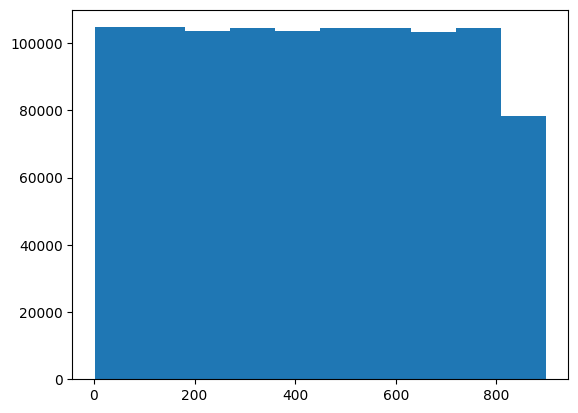

: 

In [ ]:
import matplotlib.pyplot as plt 

plt.hist(combined['BTC_time_to_close'])

In [45]:
combined.sort('curr_time')

BTC_id,curr_time,BTC_open_time,BTC_close_time,BTC_last_price_dollars,BTC_no_ask_dollars,BTC_no_bid_dollars,BTC_yes_ask_dollars,BTC_yes_bid_dollars,BTC_floor_strike,BTC_volume_24h_fp,BTC_prev_time,BTC_time_diff_seconds,BTC_time_to_close,BTC_next_price_dollars_lead1,ETH_id,ETH_open_time,ETH_close_time,ETH_last_price_dollars,ETH_no_ask_dollars,ETH_no_bid_dollars,ETH_yes_ask_dollars,ETH_yes_bid_dollars,ETH_floor_strike,ETH_volume_24h_fp,ETH_prev_time,ETH_time_diff_seconds,ETH_time_to_close,ETH_next_price_dollars_lead1,XRP_id,XRP_open_time,XRP_close_time,XRP_last_price_dollars,XRP_no_ask_dollars,XRP_no_bid_dollars,XRP_yes_ask_dollars,XRP_yes_bid_dollars,XRP_floor_strike,XRP_volume_24h_fp,XRP_prev_time,XRP_time_diff_seconds,XRP_time_to_close,XRP_next_price_dollars_lead1,SOL_id,SOL_open_time,SOL_close_time,SOL_last_price_dollars,SOL_no_ask_dollars,SOL_no_bid_dollars,SOL_yes_ask_dollars,SOL_yes_bid_dollars,SOL_floor_strike,SOL_volume_24h_fp,SOL_prev_time,SOL_time_diff_seconds,SOL_time_to_close,SOL_next_price_dollars_lead1
i64,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64
3156,2026-03-21 11:00:45.584324 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.53,3157,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.0,3158,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.47,3159,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.51
3160,2026-03-21 11:00:46.585918 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:45.584324 UTC,1,853,0.53,3161,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:45.584324 UTC,1,853,0.0,3162,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:45.584324 UTC,1,853,0.47,3163,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:45.584324 UTC,1,853,0.51
3164,2026-03-21 11:00:47.588320 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:46.585918 UTC,1,852,0.53,3165,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:46.585918 UTC,1,852,0.0,3166,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:46.585918 UTC,1,852,0.47,3167,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:46.585918 UTC,1,852,0.51
3168,2026-03-21 11:00:48.591911 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.53,3169,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.0,3170,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.47,3171,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.51
3172,2026-03-21 11:00:49.614644 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:48.591911 UTC,1,850,0.53,3173,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:48.591911 UTC,1,850,0.0,3174,2026-03-21 11:00:00 

In [14]:
btc_trades.head()

id,curr_time,product_id,trade_time,price,size,side
i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]",f64,f64,str
0,2026-03-21 10:47:31.458355 UTC,"""BTC-USD""",2026-03-21 10:47:31.433808 UTC,70565.43,0.000084,"""sell"""
1,2026-03-21 10:47:31.573966 UTC,"""BTC-USD""",2026-03-21 10:47:31.554989 UTC,70565.43,4.4000e-7,"""sell"""
2,2026-03-21 10:47:32.156989 UTC,"""BTC-USD""",2026-03-21 10:47:32.151470 UTC,70565.43,0.0001403,"""sell"""
3,2026-03-21 10:47:32.673739 UTC,"""BTC-USD""",2026-03-21 10:47:32.669946 UTC,70565.43,4.4000e-7,"""sell"""
4,2026-03-21 10:47:33.706974 UTC,"""BTC-USD""",2026-03-21 10:47:33.701132 UTC,70565.43,0.000511,"""sell"""


In [19]:
btc_kalshi_trades = combined.join_where(
    btc_trades,
    (pl.col("trade_time") >= pl.col("BTC_prev_time")) &
    (pl.col("trade_time") <= pl.col("curr_time"))
)



trade_features = (
    btc_kalshi_trades
    .with_columns([
        pl.when(pl.col("side") == "buy").then(pl.col("size")).otherwise(0).alias("buy_size"),
        pl.when(pl.col("side") == "sell").then(pl.col("size")).otherwise(0).alias("sell_size"),
        (pl.col("price") * pl.col("size")).alias("dollar_volume"),
    ])
    .group_by("curr_time")
    .agg([
        pl.len().alias("trade_count"),
        pl.col("size").sum().alias("size_sum"),
        pl.col("buy_size").sum().alias("buy_size_sum"),
        pl.col("sell_size").sum().alias("sell_size_sum"),
        (pl.col("buy_size").sum() - pl.col("sell_size").sum()).alias("size_imbalance"),
        pl.col("price").mean().alias("price_mean"),
        pl.col("price").std().alias("price_std"),
        (pl.col("dollar_volume").sum() / pl.col("size").sum()).alias("vwap"),
    ])
)


In [41]:
kalshi.filter(
    (pl.col("open_time") == pl.datetime(2026, 3, 21, 11, 0, 0, time_zone="UTC")) & (pl.col('coin') == 'BTC')
)


id,curr_time,coin,open_time,close_time,last_price_dollars,no_ask_dollars,no_bid_dollars,yes_ask_dollars,yes_bid_dollars,floor_strike,volume_24h_fp,prev_time,time_diff_seconds,time_to_close
i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64
3036,2026-03-21 11:00:15.418105 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:14.416887 UTC,1,884
3040,2026-03-21 11:00:16.419216 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:15.418105 UTC,1,883
3044,2026-03-21 11:00:17.420444 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:16.419216 UTC,1,882
3048,2026-03-21 11:00:18.421119 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:17.420444 UTC,1,881
3052,2026-03-21 11:00:19.422934 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.49,0.51,0.5,0.5,0.49,70592.55,0.0,2026-03-21 11:00:18.421119 UTC,1,880
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6540,2026-03-21 11:14:56.617700 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.001,1.0,0.999,0.001,0.0,70592.55,133450.0,2026-03-21 11:14:55.616276 UTC,1,3
6544,2026-03-21 11:14:57.618403 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.001,1.0,0.999,0.001,0.0,70592.55,133450.0,2026-03-21 11:14:56.617700 UTC,1,2
6548,2026-03-21 11:14:58.619237 UTC,"""BTC""",2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.001,1.0,0.999,0.001,0.0,70592.55,133450.0,2026-03-21 11:14:57.618403 UTC,1,1


In [24]:
btc_kalshi_trades.sort('curr_time')


BTC_id,curr_time,BTC_open_time,BTC_close_time,BTC_last_price_dollars,BTC_no_ask_dollars,BTC_no_bid_dollars,BTC_yes_ask_dollars,BTC_yes_bid_dollars,BTC_floor_strike,BTC_volume_24h_fp,BTC_prev_time,BTC_time_diff_seconds,BTC_time_to_close,BTC_next_price_dollars_lead1,ETH_id,ETH_open_time,ETH_close_time,ETH_last_price_dollars,ETH_no_ask_dollars,ETH_no_bid_dollars,ETH_yes_ask_dollars,ETH_yes_bid_dollars,ETH_floor_strike,ETH_volume_24h_fp,ETH_prev_time,ETH_time_diff_seconds,ETH_time_to_close,ETH_next_price_dollars_lead1,XRP_id,XRP_open_time,XRP_close_time,XRP_last_price_dollars,XRP_no_ask_dollars,XRP_no_bid_dollars,XRP_yes_ask_dollars,XRP_yes_bid_dollars,XRP_floor_strike,XRP_volume_24h_fp,XRP_prev_time,XRP_time_diff_seconds,XRP_time_to_close,XRP_next_price_dollars_lead1,SOL_id,SOL_open_time,SOL_close_time,SOL_last_price_dollars,SOL_no_ask_dollars,SOL_no_bid_dollars,SOL_yes_ask_dollars,SOL_yes_bid_dollars,SOL_floor_strike,SOL_volume_24h_fp,SOL_prev_time,SOL_time_diff_seconds,SOL_time_to_close,SOL_next_price_dollars_lead1,outcome,id,curr_time_right,product_id,trade_time,price,size,side
i64,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,"datetime[μs, UTC]",i64,i64,f64,i8,i64,"datetime[μs, UTC]",str,"datetime[μs, UTC]",f64,f64,str
3156,2026-03-21 11:00:45.584324 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.53,3157,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.0,3158,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.47,3159,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:44.583508 UTC,1,854,0.51,0,2009,2026-03-21 11:00:44.843820 UTC,"""BTC-USD""",2026-03-21 11:00:44.839260 UTC,70591.61,0.00014,"""sell"""
3168,2026-03-21 11:00:48.591911 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.53,3169,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.0,3170,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.47,3171,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.51,0,2011,2026-03-21 11:00:47.971488 UTC,"""BTC-USD""",2026-03-21 11:00:47.967003 UTC,70591.61,0.000688,"""sell"""
3168,2026-03-21 11:00:48.591911 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.53,3169,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.0,3170,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.47,3171,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.51,0.5,0.49,0.51,0.5,89.9495,0.0,2026-03-21 11:00:47.588320 UTC,1,851,0.51,0,2010,2026-03-21 11:00:47.772876 UTC,"""BTC-USD""",2026-03-21 11:00:47.769347 UTC,70591.61,0.0002753,"""sell"""
3180,2026-03-21 11:00:51.617205 UTC,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.53,0.47,0.46,0.54,0.53,70592.55,0.0,2026-03-21 11:00:50.615730 UTC,1,848,0.53,3181,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.0,0.57,0.41,0.59,0.43,2153.8,0.0,2026-03-21 11:00:50.615730 UTC,1,848,0.59,3182,2026-03-21 11:00:00 UTC,2026-03-21 11:15:00 UTC,0.47,0.62,0.57,0.43,0.38,1.4401,0.0,2026-03-21 11:00:50.61573

In [ ]:
btc_trades = btc_trades.with_columns(
    ((pl.col("price") * pl.col("size")) * pl.when(pl.col("side") == "buy").then(1).otherwise(-1)).alias("weighted")
)
btc_trades['weighted'].sum()


-42234454.28388647

In [ ]:
options.head()


NameError: name 'options' is not defined

In [ ]:
kalshi.head()


id,curr_time,coin,open_time,close_time,last_price_dollars,liquidity_dollars,no_ask_dollars,no_bid_dollars,yes_ask_dollars,yes_bid_dollars,open_interest,floor_strike,cap_strike,strike_type,volume,volume_24h_fp
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,str,str,str,f64
4200710,"""2026-03-23 06:21:15.231426+00:…","""XRP""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.52,0.0,0.5,0.48,0.52,0.5,null,1.3815,null,"""greater_or_equal""",null,0.0
4200711,"""2026-03-23 06:21:15.231426+00:…","""SOL""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.58,0.0,0.51,0.47,0.53,0.49,null,86.5482,null,"""greater_or_equal""",null,0.0
4200712,"""2026-03-23 06:21:16.232547+00:…","""BTC""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.62,0.0,0.38,0.37,0.63,0.62,null,68569.81,null,"""greater_or_equal""",null,0.0
4200713,"""2026-03-23 06:21:16.232547+00:…","""ETH""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.55,0.0,0.5,0.46,0.54,0.5,null,2057.469999,null,"""greater_or_equal""",null,0.0
4200714,"""2026-03-23 06:21:16.232547+00:…","""XRP""","""2026-03-23 06:15:00+00:00""","""2026-03-23 06:30:00+00:00""",0.52,0.0,0.5,0.48,0.52,0.5,null,1.3815,null,"""greater_or_equal""",null,0.0


In [ ]:
polymarket.head()

id,curr_time,coin,time_horizon_minutes,interval_start_unix,market_slug,condition_id,strike_price,end_date,liquidity,volume,open_interest,yes_implied_price,no_implied_price,yes_buy_price,yes_sell_price,no_buy_price,no_sell_price
i64,str,str,i64,i64,str,str,f64,str,f64,f64,str,f64,f64,f64,f64,f64,f64
0,"""2026-03-28 18:00:42.725060+00:…","""ETH""",15,1774720800,"""eth-updown-15m-1774720800""","""0xd9b38938db1e4c03d96213a63a73…",2019.45,"""2026-03-28 18:15:00+00:00""",38862.5508,155.27818,null,0.54,0.46,0.47,0.48,0.52,0.53
1,"""2026-03-28 18:00:42.725060+00:…","""XRP""",15,1774720800,"""xrp-updown-15m-1774720800""","""0xf49dd149e33579a84c9ea9dfbaad…",1.3462,"""2026-03-28 18:15:00+00:00""",34937.5142,63.995962,null,0.575,0.425,0.45,0.46,0.54,0.55
2,"""2026-03-28 18:00:42.725060+00:…","""SOL""",15,1774720800,"""sol-updown-15m-1774720800""","""0x8be6b4663170642c83a1d69fe5a9…",83.17,"""2026-03-28 18:15:00+00:00""",36528.5169,42.22,null,0.535,0.465,0.49,0.5,0.5,0.51
3,"""2026-03-28 18:00:43.735854+00:…","""BTC""",15,1774720800,"""btc-updown-15m-1774720800""","""0xe2debe513a849862fee606de1680…",66853.8,"""2026-03-28 18:15:00+00:00""",48924.7393,817.438353,null,0.475,0.525,0.54,0.55,0.45,0.46
4,"""2026-03-28 18:00:43.735854+00:…","""ETH""",15,1774720800,"""eth-updown-15m-1774720800""","""0xd9b38938db1e4c03d96213a63a73…",2019.45,"""2026-03-28 18:15:00+00:00""",38862.5508,155.27818,null,0.54,0.46,0.47,0.48,0.52,0.53
